In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy

In [2]:
df = pd.read_csv("test3.csv")

print(df.shape)
df.head()

(1540, 11)


,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packets/s,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,act_data_pkt_fwd,Label
0,2.023005,386.553756,5.931771,12,782,5.931771,0,12,254,12,ATTACK
1,1.909313,1174.244371,9.951223,19,2242,9.951223,0,19,547,19,ATTACK
2,2.217469,1412.421265,11.725081,26,3132,11.725081,0,26,547,26,ATTACK
3,2.224721,418.029955,6.292924,14,930,6.292924,0,14,250,14,ATTACK
4,2.028799,58537.586357,47.318634,96,118761,47.318634,20,76,64240,39,ATTACK


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1540 entries, 0 to 1539
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Flow Duration                1540 non-null   float64
 1   Flow Bytes/s                 1540 non-null   float64
 2   Flow Packets/s               1540 non-null   float64
 3   Total Fwd Packets            1540 non-null   int64  
 4   Total Length of Fwd Packets  1540 non-null   int64  
 5   Fwd Packets/s                1540 non-null   float64
 6   SYN Flag Count               1540 non-null   int64  
 7   ACK Flag Count               1540 non-null   int64  
 8   Init_Win_bytes_forward       1540 non-null   int64  
 9   act_data_pkt_fwd             1540 non-null   int64  
 10  Label                        1540 non-null   object 
dtypes: float64(4), int64(6), object(1)
memory usage: 132.5+ KB
None


In [4]:
df.isnull().sum()

Flow Duration                  0
Flow Bytes/s                   0
Flow Packets/s                 0
Total Fwd Packets              0
Total Length of Fwd Packets    0
Fwd Packets/s                  0
SYN Flag Count                 0
ACK Flag Count                 0
Init_Win_bytes_forward         0
act_data_pkt_fwd               0
Label                          0
dtype: int64

In [5]:
print(df.duplicated().sum())

0


In [6]:
df["Label"].value_counts()

Label
ATTACK    1540
Name: count, dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Flow Duration,1540.0,3.312870,1.330905,0.007693,2.715292,3.468276,4.436316,4.997871e+00
Flow Bytes/s,1540.0,6288.368436,29646.347596,42.402911,171.130702,257.613461,390.774630,4.650309e+05
Flow Packets/s,1540.0,13.463920,37.902888,0.706715,2.565930,3.838255,5.664109,4.289422e+02
Total Fwd Packets,1540.0,33.915584,99.081674,3.000000,5.000000,13.000000,19.000000,7.670000e+02
Total Length of Fwd Packets,1540.0,21733.171429,110594.279710,162.000000,345.000000,858.000000,1299.000000,1.152973e+06
Fwd Packets/s,1540.0,13.463920,37.902888,0.706715,2.565930,3.838255,5.664109,4.289422e+02
SYN Flag Count,1540.0,19.064935,99.046846,0.000000,0.000000,0.000000,1.000000,7.670000e+02
ACK Flag Count,1540.0,15.320779,21.753679,0.000000,4.000000,12.000000,18.000000,1.840000e+02
Init_Win_bytes_forward,1540.0,46799.235065,22002.457073,0.000000,53248.000000,53248.000000,53248.000000,6.553500e+04
act_data_pkt_fwd,1540.0,24.284416,100.937295,0.000000,0.000000,0.000000,0.000000,7.670000e+02


In [8]:
df.median(numeric_only=True)

Flow Duration                      3.468276
Flow Bytes/s                     257.613461
Flow Packets/s                     3.838255
Total Fwd Packets                 13.000000
Total Length of Fwd Packets      858.000000
Fwd Packets/s                      3.838255
SYN Flag Count                     0.000000
ACK Flag Count                    12.000000
Init_Win_bytes_forward         53248.000000
act_data_pkt_fwd                   0.000000
dtype: float64

In [9]:
features = [
'Flow Duration',
'Flow Bytes/s',
'Flow Packets/s',
'Total Fwd Packets',
'Total Length of Fwd Packets',
'Fwd Packets/s',
'SYN Flag Count',
'ACK Flag Count',
'Init_Win_bytes_forward',
'act_data_pkt_fwd'
]

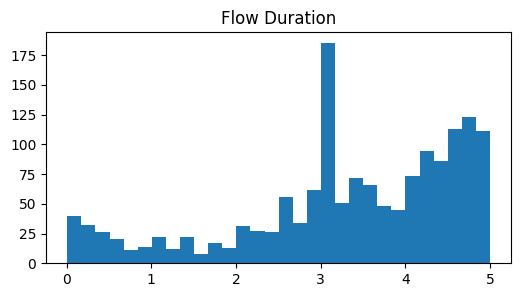

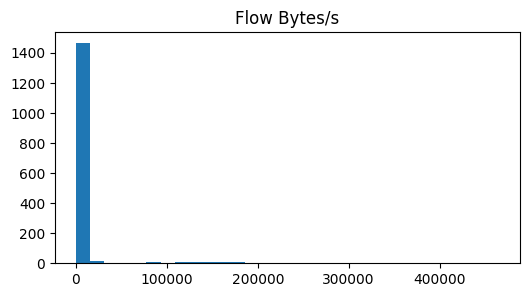

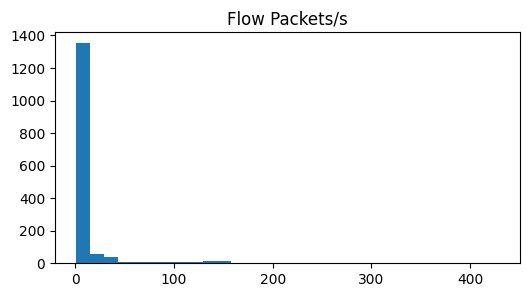

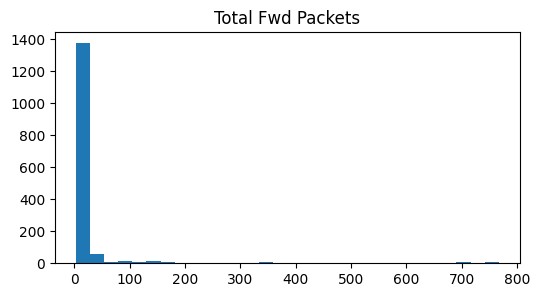

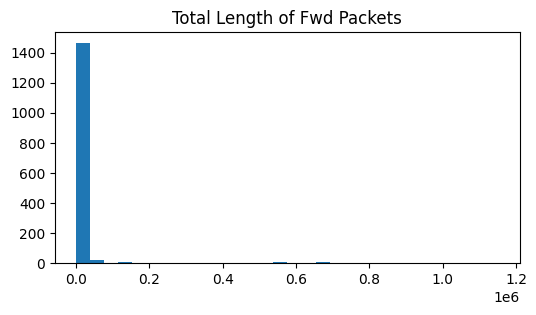

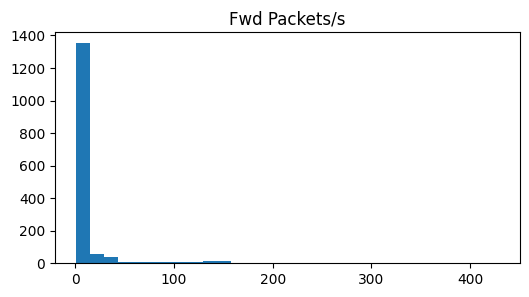

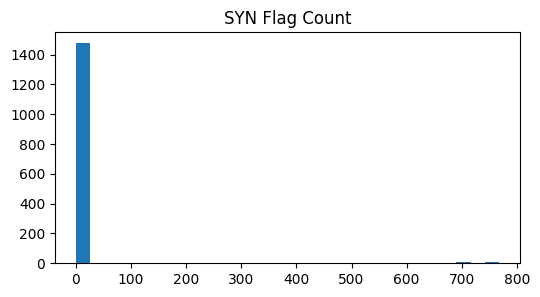

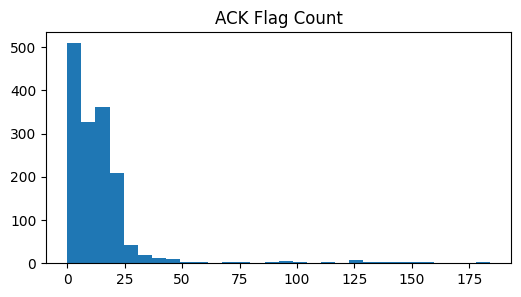

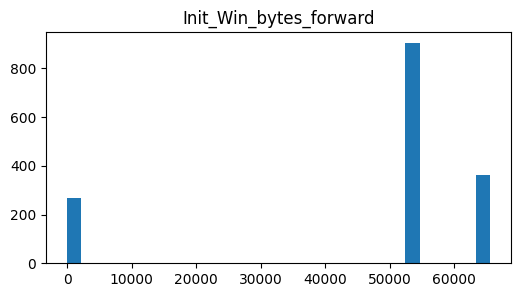

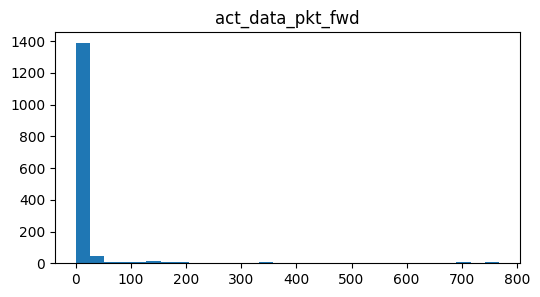

In [10]:
for col in features:

    plt.figure(figsize=(6,3))

    plt.hist(df[col], bins=30)

    plt.title(col)

    plt.show()

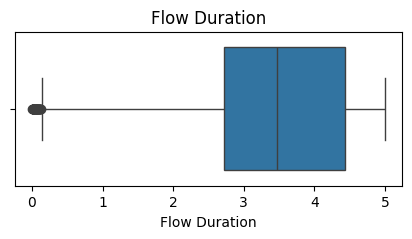

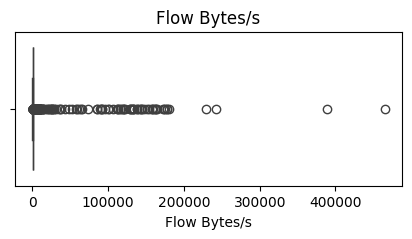

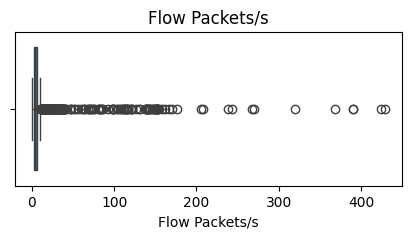

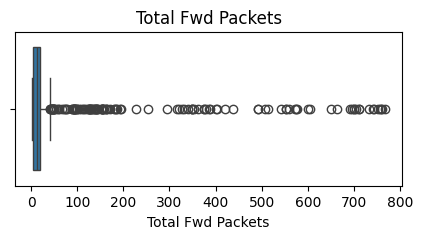

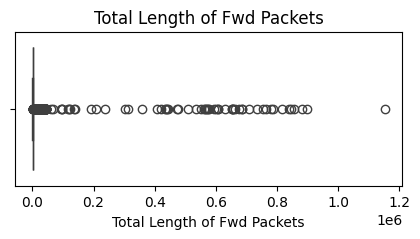

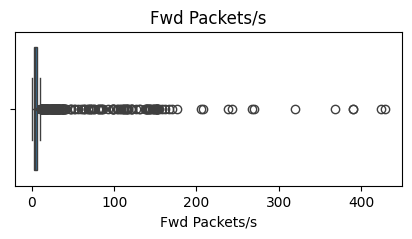

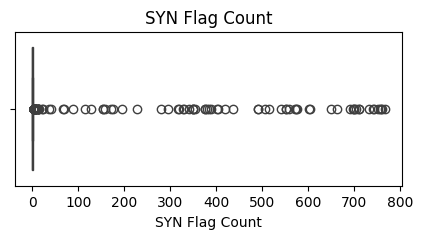

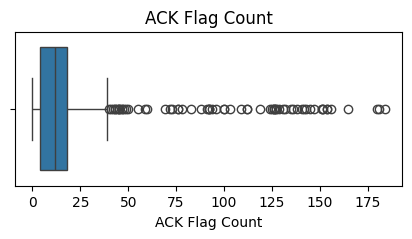

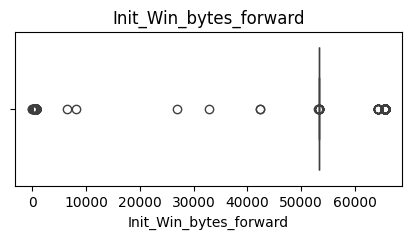

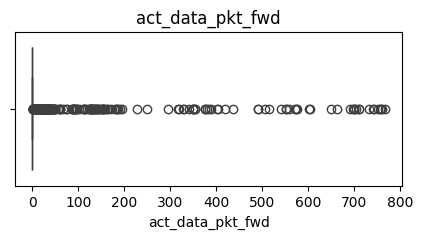

In [11]:
for col in features:

    plt.figure(figsize=(5,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

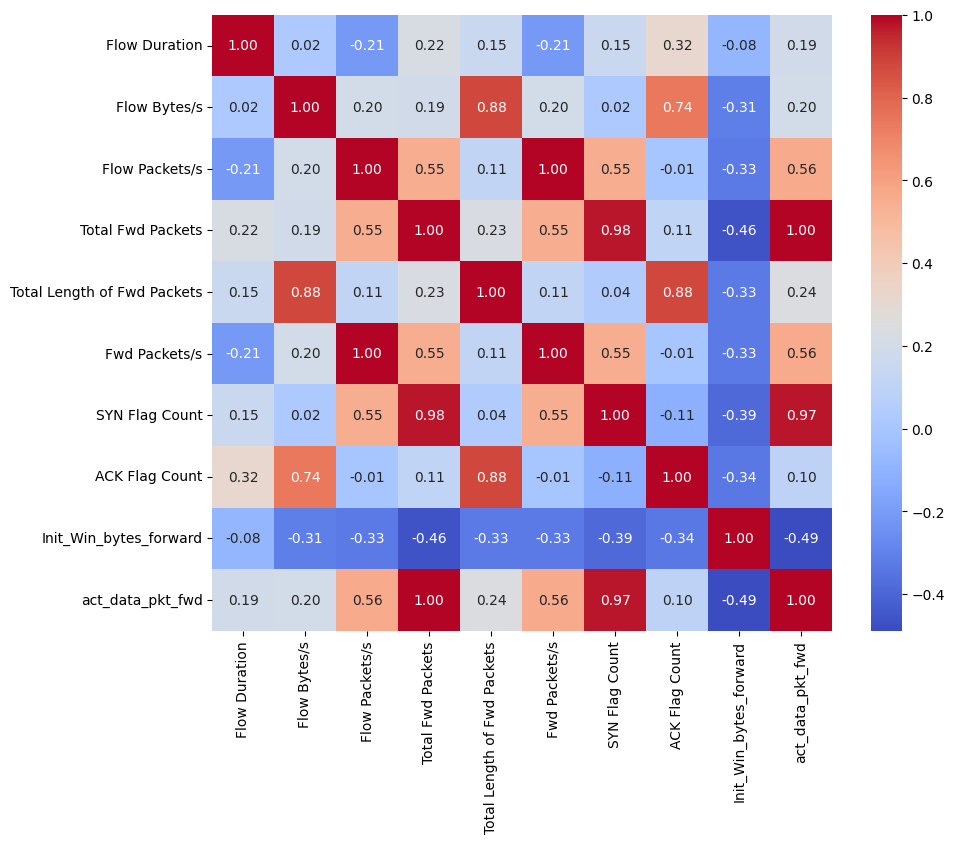

In [12]:
corr = df[features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [13]:
df[features].var().sort_values()

Flow Duration                  1.771307e+00
ACK Flag Count                 4.732226e+02
Flow Packets/s                 1.436629e+03
Fwd Packets/s                  1.436629e+03
SYN Flag Count                 9.810278e+03
Total Fwd Packets              9.817178e+03
act_data_pkt_fwd               1.018834e+04
Init_Win_bytes_forward         4.841081e+08
Flow Bytes/s                   8.789059e+08
Total Length of Fwd Packets    1.223109e+10
dtype: float64

In [14]:
for col in features:

    print(col)

    print(df[col].nunique())

Flow Duration
1540
Flow Bytes/s
1540
Flow Packets/s
1540
Total Fwd Packets
146
Total Length of Fwd Packets
441
Fwd Packets/s
1540
SYN Flag Count
76
ACK Flag Count
92
Init_Win_bytes_forward
27
act_data_pkt_fwd
144


In [15]:
for col in features:

    counts = df[col].value_counts()

    e = entropy(counts)

    print(col, e)

Flow Duration 7.339537695407673
Flow Bytes/s 7.339537695407673
Flow Packets/s 7.339537695407673
Total Fwd Packets 3.4581466289895797
Total Length of Fwd Packets 4.718454323361186
Fwd Packets/s 7.339537695407673
SYN Flag Count 1.1384784011807352
ACK Flag Count 3.3156781230466343
Init_Win_bytes_forward 1.4706772962832952
act_data_pkt_fwd 1.4532678189679287


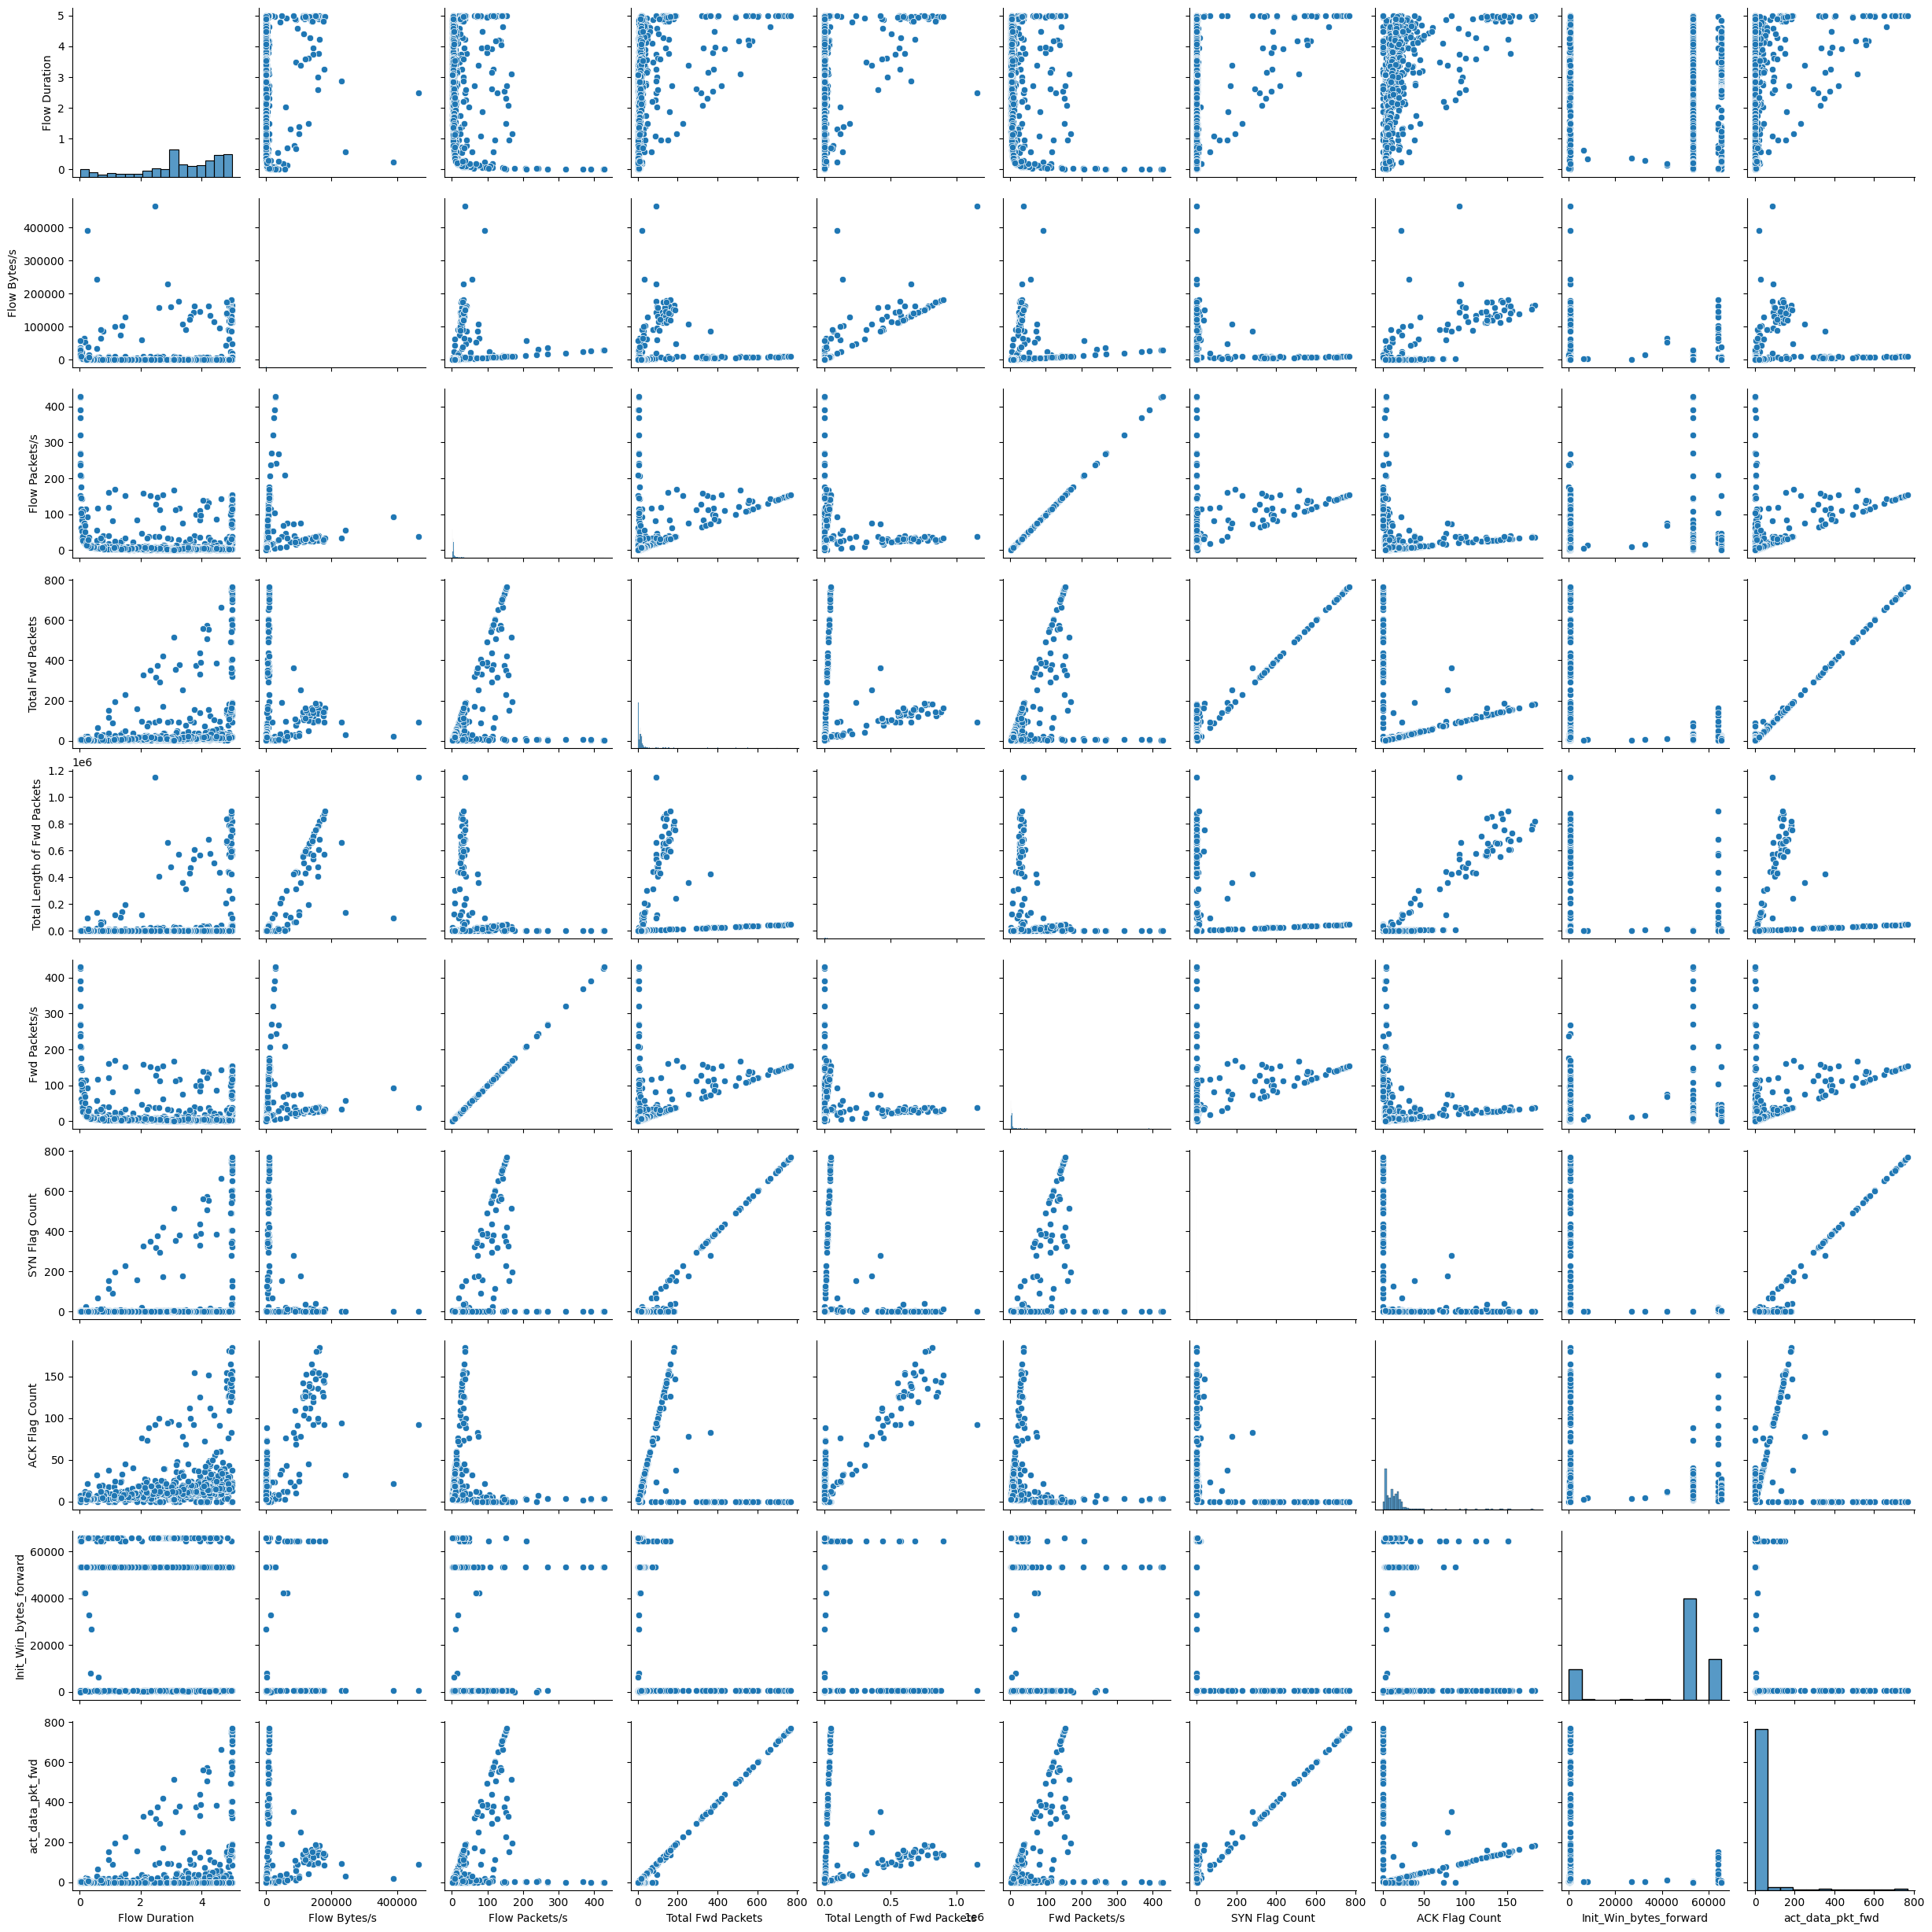

In [16]:
sns.pairplot(
    df[features]
)

In [17]:
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

In [18]:
X = df[features]

X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

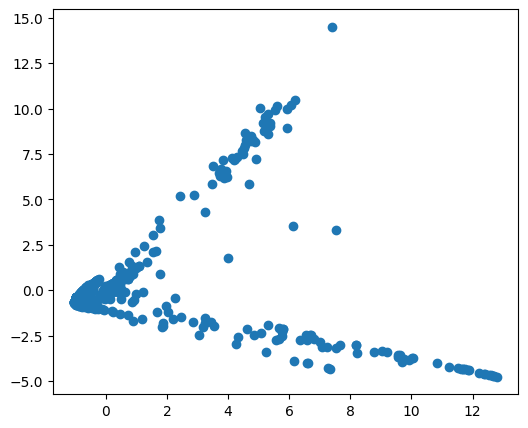

In [19]:
plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.show()

In [20]:
corr = abs(df[features].corr())

corr

,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packets/s,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,act_data_pkt_fwd
Flow Duration,1.000000,0.022841,0.212024,0.222770,0.154103,0.212024,0.152439,0.316062,0.084326,0.186420
Flow Bytes/s,0.022841,1.000000,0.195840,0.186664,0.882046,0.195840,0.022823,0.741059,0.310860,0.195578
Flow Packets/s,0.212024,0.195840,1.000000,0.552060,0.111864,1.000000,0.550717,0.005505,0.330977,0.559152
Total Fwd Packets,0.222770,0.186664,0.552060,1.000000,0.230995,0.552060,0.975229,0.107557,0.464272,0.996825
Total Length of Fwd Packets,0.154103,0.882046,0.111864,0.230995,1.000000,0.111864,0.036271,0.882450,0.327501,0.239377
Fwd Packets/s,0.212024,0.195840,1.000000,0.552060,0.111864,1.000000,0.550717,0.005505,0.330977,0.559152
SYN Flag Count,0.152439,0.022823,0.550717,0.975229,0.036271,0.550717,1.000000,0.114683,0.385979,0.974938
ACK Flag Count,0.316062,0.741059,0.005505,0.107557,0.882450,0.005505,0.114683,1.000000,0.335767,0.096005
Init_Win_bytes_forward,0.084326,0.310860,0.330977,0.464272,0.327501,0.330977,0.385979,0.335767,1.000000,0.488772
act_data_pkt_fwd,0.186420,0.195578,0.559152,0.996825,0.239377,0.559152,0.974938,0.096005,0.488772,1.000000


In [21]:
for col in features:

    print(
        col,
        df[col].std()
    )

Flow Duration 1.3309046691782564
Flow Bytes/s 29646.34759559053
Flow Packets/s 37.902888011796094
Total Fwd Packets 99.08167365645386
Total Length of Fwd Packets 110594.2797100464
Fwd Packets/s 37.902888011796094
SYN Flag Count 99.04684640106962
ACK Flag Count 21.753679456421743
Init_Win_bytes_forward 22002.457073359932
act_data_pkt_fwd 100.93729493480124
